In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, confusion_matrix, roc_auc_score,
                             roc_curve, precision_recall_curve, f1_score, recall_score,
                             precision_score, brier_score_loss)
from sklearn.calibration import calibration_curve
import xgboost as xgb
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import time
import warnings
from scipy.stats import chi2_contingency, mannwhitneyu, ks_2samp
from statsmodels.stats.proportion import proportions_ztest
from scipy.stats import kruskal

tf.random.set_seed(14)

In [ ]:
def load_and_explore_data(file_path):
    try:
        df = pd.read_csv(file_path)
        print(f"✓ Dataset loaded successfully! Shape: {df.shape}")
    except FileNotFoundError:
        print(f"✗ File not found at '{file_path}'.")
    print("\nDataset Overview:")
    print(f"  Rows: {df.shape[0]:,}")
    print(f"  Columns: {df.shape[1]}")
    print(f"  Memory usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

    # Identify the target variable
    if 'fraud_bool' in df.columns:
        target_col = 'fraud_bool'
    elif 'is_fraud' in df.columns:
        target_col = 'is_fraud'
    else:
        target_col = df.columns[-1]
        print(f"Assuming '{target_col}' is the target variable.")

    print(f"\nClass Distribution ('{target_col}'):")
    print(df[target_col].value_counts())
    print(f"Fraud rate: {df[target_col].mean():.2%}")

    missing_data = df.isnull().sum()
    if missing_data.sum() > 0:
        print("\nMissing Values:")
        missing_data = missing_data[missing_data > 0].sort_values(ascending=False)
        for col, count in missing_data.items():
            print(f"  {col}: {count} ({count/len(df):.2%})")
    else:
        print("\n✓ No missing values found.")

    print("\nData Types:")
    print(df.dtypes.value_counts())

    return df, target_col

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def eda(df, target_col):
    print("\nExploratory Data Analysis (EDA)")

    #Key Distributions
    fig1, axes1 = plt.subplots(2, 2, figsize=(16, 12))
    fig1.suptitle('EDA: Key Variable Distributions', fontsize=18)
    axes1 = axes1.flatten() # Flatten the 2x2 array for easy iteration

    # 1. Target distribution
    df[target_col].value_counts().plot(kind='bar', color=['skyblue', 'salmon'], ax=axes1[0])
    axes1[0].set_title('Target Distribution')
    axes1[0].set_xlabel('Class (0=Legitimate, 1=Fraud)')
    axes1[0].set_ylabel('Count')
    axes1[0].tick_params(axis='x', rotation=0)

    # 2. Fraud rate by month (conditional)
    if 'month' in df.columns:
        df.groupby('month')[target_col].mean().plot(kind='line', marker='o', color='red', ax=axes1[1])
        axes1[1].set_title('Fraud Rate by Month')
        axes1[1].set_xlabel('Month')
        axes1[1].set_ylabel('Fraud Rate')
        axes1[1].grid(True, alpha=0.5)

    # 3. Age distribution by fraud status (conditional)
    if 'customer_age' in df.columns:
        sns.kdeplot(data=df, x='customer_age', hue=target_col, fill=True, common_norm=False, ax=axes1[2])
        axes1[2].set_title('Age Distribution by Fraud Status')
        axes1[2].set_xlabel('Customer Age')

    # 4. Income distribution by fraud status (conditional)
    if 'income' in df.columns:
        # Use a temporary column for log transformation
        df['log_income'] = np.log1p(df['income'])
        sns.kdeplot(data=df, x='log_income', hue=target_col, fill=True, common_norm=False, ax=axes1[3])
        axes1[3].set_title('Income Distribution (Log Scale)')
        axes1[3].set_xlabel('Log(Income)')
        df.drop('log_income', axis=1, inplace=True)

    for ax in axes1:
        if not ax.has_data(): # Check if the axes has been plotted on
            ax.set_visible(False)

    plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to make room for suptitle
    plt.show()

    # --- Figure 2: Feature Analysis (Set of up to 4) ---
    fig2, axes2 = plt.subplots(2, 2, figsize=(16, 12))
    fig2.suptitle('EDA: Feature Analysis & Correlations', fontsize=18)
    axes2 = axes2.flatten()

    # 5. Correlation heatmap
    numeric_cols = df.select_dtypes(include=np.number).columns
    if len(numeric_cols) > 1:
        correlation_matrix = df[numeric_cols].corr()
        sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', center=0, ax=axes2[0])
        axes2[0].set_title('Feature Correlation Matrix')

    # 6. Top features correlated with target
    if len(numeric_cols) > 1:
        corr_with_target = df[numeric_cols].corr()[target_col].abs().sort_values(ascending=False)
        corr_with_target.drop(target_col).head(10).sort_values().plot(kind='barh', color='lightgreen', ax=axes2[1])
        axes2[1].set_title('Top 10 Features by Correlation')
        axes2[1].set_xlabel('Absolute Correlation with Target')

    # 7. Fraud rate by employment status (conditional)
    if 'employment_status' in df.columns:
        df.groupby('employment_status')[target_col].mean().plot(kind='bar', color='orange', ax=axes2[2])
        axes2[2].set_title('Fraud Rate by Employment Status')
        axes2[2].set_xlabel('Employment Status')
        axes2[2].set_ylabel('Fraud Rate')
        axes2[2].tick_params(axis='x', rotation=45)

    # 8. Distribution of key numeric features (conditional)
    key_numeric = [col for col in ['account_balance', 'transaction_count'] if col in df.columns]
    if key_numeric:
        df[key_numeric].plot(kind='box', vert=False, ax=axes2[3])
        axes2[3].set_title('Distribution of Key Numeric Features')

    for ax in axes2:
        if not ax.has_data():
            ax.set_visible(False)

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

    # Dynamically determine the number of plots for this figure
    plots_needed = 1 # Pie chart
    if 'customer_age' in df.columns:
        plots_needed += 1

    fig3, axes3 = plt.subplots(1, plots_needed, figsize=(8 * plots_needed, 6), squeeze=False)
    axes3 = axes3.flatten() # Ensure axes3 is always a flat array
    fig3.suptitle('EDA: Class Imbalance & Age Demographics', fontsize=16)

    # 9. Class imbalance pie chart
    fraud_counts = df[target_col].value_counts()
    imbalance_ratio = fraud_counts.get(0, 0) / fraud_counts.get(1, 1) if fraud_counts.get(1, 0) > 0 else float('inf')
    axes3[0].pie(fraud_counts, labels=['Legitimate', 'Fraud'], autopct='%1.2f%%', colors=['lightblue', 'lightcoral'], startangle=90)
    axes3[0].set_title(f'Class Imbalance\nRatio: {imbalance_ratio:.1f}:1')

    # 10. Fraud rate by age group (conditional)
    if 'customer_age' in df.columns:
        # Use a temporary column for age grouping
        df['age_group'] = pd.cut(df['customer_age'], bins=[0, 30, 50, 100], labels=['Young', 'Middle', 'Senior'])
        df.groupby('age_group')[target_col].mean().plot(kind='bar', color='purple', ax=axes3[1])
        axes3[1].set_title('Fraud Rate by Age Group')
        axes3[1].set_xlabel('Age Group')
        axes3[1].set_ylabel('Fraud Rate')
        axes3[1].tick_params(axis='x', rotation=0)
        df.drop('age_group', axis=1, inplace=True)

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

In [ ]:
def preprocess_data(df, target_col):
    print("\nPreprocessing Data")
    X = df.drop(columns=[target_col])
    y = df[target_col]

    categorical_cols = X.select_dtypes(include=['object', 'category']).columns
    numerical_cols = X.select_dtypes(include=np.number).columns
    print(f"Found {len(categorical_cols)} categorical and {len(numerical_cols)} numerical columns.")

    X_processed = X.copy()
    le_dict = {}

    # Encode categorical variables
    if len(categorical_cols) > 0:
        for col in categorical_cols:
            X_processed[col] = X_processed[col].astype(str).fillna('missing')
            le = LabelEncoder()
            X_processed[col] = le.fit_transform(X_processed[col])
            le_dict[col] = le
        print("✓ Categorical features encoded.")

    # Fill missing numerical values with the median
    if X_processed[numerical_cols].isnull().sum().sum() > 0:
        for col in numerical_cols:
            if X_processed[col].isnull().any():
                median_val = X_processed[col].median()
                X_processed[col].fillna(median_val, inplace=True)
        print("✓ Missing numerical values filled with median.")

    # Scale numerical features
    print("Applying StandardScaler to features...")
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_processed)
    X_scaled = pd.DataFrame(X_scaled, columns=X_processed.columns, index=X_processed.index)

    print(f"✓ Preprocessing complete. Final feature shape: {X_scaled.shape}")
    return X_scaled, y, scaler, le_dict


In [ ]:
def tensorflow_model(input_dim, model_type='standard'):
    tf.random.set_seed(14)
    if model_type == 'standard':
        # A standard, general-purpose neural network
        model = keras.Sequential([
            layers.Dense(128, activation='relu', input_shape=(input_dim,)),
            layers.Dropout(0.3),
            layers.Dense(64, activation='relu'),
            layers.Dropout(0.2),
            layers.Dense(32, activation='relu'),
            layers.Dense(1, activation='sigmoid')
        ])
    elif model_type == 'bayesian':
        # An approximate Bayesian NN using higher dropout for uncertainty estimation
        model = keras.Sequential([
            layers.Dense(128, activation='relu', input_shape=(input_dim,)),
            layers.Dropout(0.5),
            layers.Dense(64, activation='relu'),
            layers.Dropout(0.4),
            layers.Dense(32, activation='relu'),
            layers.Dropout(0.3),
            layers.Dense(1, activation='sigmoid')
        ])
    elif model_type == 'deep':
        # A deeper network for potentially more complex patterns
        model = keras.Sequential([
            layers.Dense(256, activation='relu', input_shape=(input_dim,)),
            layers.BatchNormalization(),
            layers.Dropout(0.3),
            layers.Dense(128, activation='relu'),
            layers.BatchNormalization(),
            layers.Dropout(0.2),
            layers.Dense(64, activation='relu'),
            layers.Dense(1, activation='sigmoid')
        ])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss='binary_crossentropy',
        metrics=['accuracy', tf.keras.metrics.Precision(), tf.keras.metrics.Recall()]
    )
    return model

In [ ]:
def bayesian_neural_network(X_train, X_test, y_train, y_test):

    print("\nTraining Bayesian Neural Network")
    tf.random.set_seed(14)
    class_weight = {0: 1.0, 1: (y_train == 0).sum() / (y_train == 1).sum()}

    model = tensorflow_model(X_train.shape[1], 'bayesian')
    early_stopping = keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

    print("Training Bayesian NN...")
    start_time = time.time()
    history = model.fit(X_train, y_train, epochs=100, batch_size=32, validation_split=0.2,
                        class_weight=class_weight, callbacks=[early_stopping], verbose=0)
    training_time = time.time() - start_time

    # Perform Monte Carlo inference to get uncertainty
    print("Performing Monte Carlo inference for uncertainty...")
    n_samples = 100
    predictions = np.array([model(X_test, training=True).numpy().flatten() for _ in range(n_samples)])

    mean_pred = np.mean(predictions, axis=0)
    uncertainty = np.std(predictions, axis=0)
    y_pred = (mean_pred > 0.5).astype(int)

    auc_score = roc_auc_score(y_test, mean_pred)
    f1 = f1_score(y_test, y_pred)
    print(f"✓ Bayesian NN trained in {training_time:.2f}s. AUC: {auc_score:.4f}, F1: {f1:.4f}")

    return {
        'name': 'Bayesian NN',
        'model': model,
        'y_pred': y_pred,
        'y_pred_proba': mean_pred,
        'uncertainty': uncertainty,
        'training_time': training_time,
        'history': history.history
    }

In [ ]:
def train_models(X_train, X_test, y_train, y_test):
    models = {}
    class_weight_balanced = {0: 1.0, 1: (y_train == 0).sum() / (y_train == 1).sum()}

    # 1. Logistic Regression
    print("1. Training Logistic Regression...")
    start_time = time.time()
    lr = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=14, solver='liblinear')
    lr.fit(X_train, y_train)
    training_time = time.time() - start_time
    models['Logistic Regression'] = {'model': lr, 'training_time': training_time}
    print(f"   ✓ Completed in {training_time:.2f}s")

    # 2. XGBoost
    print("2. Training XGBoost...")
    start_time = time.time()
    scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
    xgb_model = xgb.XGBClassifier(n_estimators=100, max_depth=6, learning_rate=0.1,
                                  scale_pos_weight=scale_pos_weight, random_state=14,
                                  eval_metric='logloss', use_label_encoder=False)
    xgb_model.fit(X_train, y_train)
    training_time = time.time() - start_time
    models['XGBoost'] = {'model': xgb_model, 'training_time': training_time}
    print(f"   ✓ Completed in {training_time:.2f}s")

    # 3. Standard TensorFlow NN
    print("3. Training Standard TensorFlow NN...")
    start_time = time.time()
    tf_model = tensorflow_model(X_train.shape[1], 'standard')
    early_stopping = keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
    history = tf_model.fit(X_train, y_train, epochs=100, batch_size=32, validation_split=0.2,
                           class_weight=class_weight_balanced, callbacks=[early_stopping], verbose=0)
    training_time = time.time() - start_time
    models['TensorFlow NN'] = {'model': tf_model, 'training_time': training_time, 'history': history.history}
    print(f"   ✓ Completed in {training_time:.2f}s")

    # 4. Deep TensorFlow NN
    print("4. Training Deep TensorFlow NN...")
    start_time = time.time()
    deep_model = tensorflow_model(X_train.shape[1], 'deep')
    early_stopping = keras.callbacks.EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)
    lr_scheduler = keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5)
    history = deep_model.fit(X_train, y_train, epochs=150, batch_size=64, validation_split=0.2,
                             class_weight=class_weight_balanced, callbacks=[early_stopping, lr_scheduler], verbose=0)
    training_time = time.time() - start_time
    models['Deep TensorFlow NN'] = {'model': deep_model, 'training_time': training_time, 'history': history.history}
    print(f"   ✓ Completed in {training_time:.2f}s")

    # 5. Bayesian NN
    bnn_results = bayesian_neural_network(X_train, X_test, y_train, y_test)
    models['Bayesian NN'] = {k: v for k, v in bnn_results.items() if k != 'name'}

    # Evaluate all models
    print("\nEvaluating model performance...")
    for name, data in models.items():
        model = data['model']

        # Check for pre-calculated predictions (for Bayesian model)
        if 'y_pred_proba' in data:
            y_pred_proba = data['y_pred_proba']
            y_pred = data['y_pred']

        # Use isinstance() for a robust check of TensorFlow/Keras models
        elif isinstance(model, tf.keras.Model):
            y_pred_proba = model.predict(X_test, verbose=0).flatten()
            y_pred = (y_pred_proba > 0.5).astype(int)

        # Fallback for scikit-learn compatible models
        else:
            y_pred_proba = model.predict_proba(X_test)[:, 1]
            y_pred = model.predict(X_test)

        # Store results and calculate metrics
        data['y_pred'] = y_pred
        data['y_pred_proba'] = y_pred_proba
        data['auc'] = roc_auc_score(y_test, y_pred_proba)
        data['f1'] = f1_score(y_test, y_pred, zero_division=0)
        data['precision'] = precision_score(y_test, y_pred, zero_division=0)
        data['recall'] = recall_score(y_test, y_pred, zero_division=0)

        print(f"  {name:<20} -> AUC: {data['auc']:.4f}, F1: {data['f1']:.4f}, Precision: {data['precision']:.4f}, Recall: {data['recall']:.4f}")

    return models

In [ ]:
def statistical_fairness_analysis(models, X_test, y_test, df_original):
    protected_attrs = {}
    test_indices = X_test.index

    if 'gender' in df_original.columns:
        protected_attrs['gender'] = df_original.loc[test_indices, 'gender'].values
    if 'customer_age' in df_original.columns:
        age_values = df_original.loc[test_indices, 'customer_age'].values
        protected_attrs['age_group'] = (age_values > np.median(age_values)).astype(int)
    if 'region' in df_original.columns:
        protected_attrs['region'] = df_original.loc[test_indices, 'region'].values

    if not protected_attrs:
        print("No protected attributes found. Skipping fairness analysis.")
        return {}

    print(f"Analyzing fairness across: {list(protected_attrs.keys())}")
    fairness_results = {}

    for model_name, model_data in models.items():
        print(f"\n--- Fairness Tests for: {model_name} ---")
        y_pred = model_data['y_pred']
        fairness_results[model_name] = {}

        for attr_name, protected_attr in protected_attrs.items():
            print(f"\n  Attribute: {attr_name.upper()}")

            contingency_table = pd.crosstab(protected_attr, y_pred)
            _, p_val_chi2, _, _ = chi2_contingency(contingency_table)
            print(f"    Chi-Square p-value: {p_val_chi2:.4f} ({'Potential Bias' if p_val_chi2 < 0.05 else 'Fair'})")

            groups = np.unique(protected_attr)
            counts = [y_pred[protected_attr == g].sum() for g in groups]
            nobs = [len(y_pred[protected_attr == g]) for g in groups]

            p_val_dp = 1.0
            dp_difference = 0.0
            rate_group_0 = 0.0
            rate_group_1 = 0.0

            if len(groups) == 2 and nobs[0] > 0 and nobs[1] > 0:
                _, p_val_dp = proportions_ztest(counts, nobs)
                rate_group_0 = counts[0] / nobs[0]
                rate_group_1 = counts[1] / nobs[1]
                dp_difference = abs(rate_group_0 - rate_group_1)

                print(f"    Demographic Parity p-value: {p_val_dp:.4f} ({'Potential Bias' if p_val_dp < 0.05 else 'Fair'})")
                print(f"      - Positive Rate (Group 0): {rate_group_0:.2%}")
                print(f"      - Positive Rate (Group 1): {rate_group_1:.2%}")
                print(f"      - Difference (Effect Size): {dp_difference:.2%}")

            fairness_results[model_name][attr_name] = {
                'chi2_p_value': p_val_chi2, 'dp_p_value': p_val_dp,
                'dp_difference': dp_difference, 'rate_group_0': rate_group_0,
                'rate_group_1': rate_group_1
            }

    model_names = list(fairness_results.keys())

    # Loop through each protected attribute
    for attr_name in protected_attrs.keys():
        # Check if demographic parity was calculated for this attribute
        is_binary = all('dp_difference' in fairness_results[m][attr_name] for m in model_names)
        if not is_binary:
            print(f"\nSkipping visualization for '{attr_name}' as it is not a binary group.")
            continue

        dp_differences = [fairness_results[m][attr_name]['dp_difference'] for m in model_names]
        rates_g0 = [fairness_results[m][attr_name]['rate_group_0'] for m in model_names]
        rates_g1 = [fairness_results[m][attr_name]['rate_group_1'] for m in model_names]

        fig, axes = plt.subplots(1, 2, figsize=(18, 7))
        fig.suptitle(f"Fairness Analysis for Attribute: '{attr_name.upper()}'", fontsize=18)

        # Plot 1: Bias Magnitude
        axes[0].bar(model_names, dp_differences, color='salmon')
        axes[0].set_title('Demographic Parity Difference (Bias Magnitude)')
        axes[0].set_ylabel('Absolute Difference in Positive Rates')
        axes[0].tick_params(axis='x', rotation=45)
        axes[0].grid(axis='y', linestyle='--', alpha=0.7)
        axes[0].axhline(y=0.20, color='r', linestyle=':', lw=2, label='20% Threshold')
        axes[0].legend()

        # Plot 2: Group Rates
        x = np.arange(len(model_names))
        width = 0.35
        axes[1].bar(x - width/2, rates_g0, width, label='Group 0')
        axes[1].bar(x + width/2, rates_g1, width, label='Group 1')
        axes[1].set_title('Positive Prediction Rate by Group')
        axes[1].set_ylabel('Positive Rate (%)')
        axes[1].set_xticks(x)
        axes[1].set_xticklabels(model_names, rotation=45, ha='right')
        axes[1].legend()
        axes[1].grid(axis='y', linestyle='--', alpha=0.7)

        plt.tight_layout(rect=[0, 0.03, 1, 0.93])
        plt.show()

    return fairness_results

In [ ]:
def threshold_analysis(models, y_test):
    print("\nPerforming Threshold Tuning Analysis")
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    axes = axes.flatten()
    fig.suptitle('Threshold Analysis: Precision, Recall & F1-Score', fontsize=16)
    thresholds = np.linspace(0.01, 0.99, 50)

    for idx, (name, model_data) in enumerate(models.items()):
        if idx >= len(axes): break
        ax = axes[idx]
        y_pred_proba = model_data['y_pred_proba']

        scores = {'f1': [], 'precision': [], 'recall': []}
        for thresh in thresholds:
            y_pred_thresh = (y_pred_proba >= thresh).astype(int)
            scores['f1'].append(f1_score(y_test, y_pred_thresh))
            scores['precision'].append(precision_score(y_test, y_pred_thresh, zero_division=0))
            scores['recall'].append(recall_score(y_test, y_pred_thresh, zero_division=0))

        ax.plot(thresholds, scores['f1'], label='F1-Score', lw=2)
        ax.plot(thresholds, scores['precision'], label='Precision', ls='--')
        ax.plot(thresholds, scores['recall'], label='Recall', ls='--')

        optimal_idx = np.argmax(scores['f1'])
        optimal_threshold = thresholds[optimal_idx]
        ax.axvline(x=optimal_threshold, color='red', ls=':', label=f'Optimal: {optimal_threshold:.2f}')

        ax.set_title(name)
        ax.set_xlabel('Threshold')
        ax.set_ylabel('Score')
        ax.legend()
        ax.grid(True, alpha=0.3)


    for i in range(idx + 1, len(axes)):
      axes[i].set_visible(False)

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

In [ ]:
def calibration_analysis(models, y_test):
    print("\nPerforming Model Calibration Analysis")
    fig, ax = plt.subplots(1, 1, figsize=(10, 8))

    for name, model_data in models.items():
        y_pred_proba = model_data['y_pred_proba']
        fraction_of_positives, mean_predicted_value = calibration_curve(y_test, y_pred_proba, n_bins=10)

        brier_score = brier_score_loss(y_test, y_pred_proba)
        model_data['brier_score'] = brier_score

        ax.plot(mean_predicted_value, fraction_of_positives, "s-", label=f"{name} (Brier: {brier_score:.3f})")

    ax.plot([0, 1], [0, 1], "k:", label="Perfectly calibrated")
    ax.set_xlabel("Mean Predicted Probability")
    ax.set_ylabel("Fraction of Positives")
    ax.set_title('Model Calibration Curves')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.show()

In [ ]:
import math

def comprehensive_evaluation_report(models, y_test):
    print("\nComprehensive Evaluation Report")

    # --- Model Performance Summary Table ---
    print("\nModel Performance Summary:")

    print(f"{'Model':<20} | {'AUC':<10} | {'F1-Score':<10} | {'Precision':<10} | {'Recall':<10} | {'Brier Score':<15}")
    for name, data in models.items():
        brier = data.get('brier_score', 'N/A')
        brier_str = f"{brier:.4f}" if isinstance(brier, float) else brier
        print(f"{name:<20} | {data['auc']:.4f}     | {data['f1']:.4f}     | {data['precision']:.4f}    | {data['recall']:.4f}   | {brier_str}")

    # Performance Curves & Feature Importance
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle('Model Evaluation Visualizations', fontsize=16)

    # ROC Curves
    ax1 = axes[0, 0]
    for name, data in models.items():
        fpr, tpr, _ = roc_curve(y_test, data['y_pred_proba'])
        ax1.plot(fpr, tpr, label=f"{name} (AUC: {data['auc']:.3f})")
    ax1.plot([0, 1], [0, 1], 'k--')
    ax1.set_title('ROC Curves')
    ax1.set_xlabel('False Positive Rate')
    ax1.set_ylabel('True Positive Rate')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # Precision-Recall Curves
    ax2 = axes[0, 1]
    for name, data in models.items():
        precision, recall, _ = precision_recall_curve(y_test, data['y_pred_proba'])
        ax2.plot(recall, precision, label=name)
    ax2.set_title('Precision-Recall Curves')
    ax2.set_xlabel('Recall')
    ax2.set_ylabel('Precision')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    # Feature Importance (from XGBoost)
    ax3 = axes[1, 0]
    if 'XGBoost' in models:
        xgb_model = models['XGBoost']['model']
        feature_names = xgb_model.get_booster().feature_names
        importances = xgb_model.feature_importances_
        feature_imp = pd.Series(importances, index=feature_names).nlargest(10)
        feature_imp.plot(kind='barh', ax=ax3, color='skyblue')
        ax3.set_title('Top 10 Feature Importances (XGBoost)')
        ax3.invert_yaxis()
    else:
        ax3.text(0.5, 0.5, 'XGBoost model not available.', ha='center', va='center')

    # Training History.
    ax4 = axes[1, 1]
    for name, data in models.items():
        if 'history' in data and 'val_loss' in data['history']:
             ax4.plot(data['history']['val_loss'], label=f'{name} Val Loss')
    ax4.set_title('Model Validation Loss History')
    ax4.set_xlabel('Epoch')
    ax4.set_ylabel('Loss')
    ax4.legend()
    ax4.grid(True, alpha=0.3)

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

    num_models = len(models)
    n_cols = 3  # Display 3 matrices per row
    n_rows = math.ceil(num_models / n_cols)

    fig_cm, axes_cm = plt.subplots(n_rows, n_cols, figsize=(n_cols * 5, n_rows * 5))
    fig_cm.suptitle('Confusion Matrices for All Models', fontsize=18)
    axes_cm = axes_cm.flatten()

    for idx, (name, data) in enumerate(models.items()):
        ax = axes_cm[idx]
        cm = confusion_matrix(y_test, data['y_pred'])
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                    xticklabels=['Legitimate', 'Fraud'], yticklabels=['Legitimate', 'Fraud'])
        ax.set_title(name)
        ax.set_ylabel('True Label')
        ax.set_xlabel('Predicted Label')

    for i in range(num_models, len(axes_cm)):
        axes_cm[i].set_visible(False)

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

In [ ]:
file_path = "Base.csv"

df, target_col = load_and_explore_data(file_path)
df_original = df.copy() # Keep a copy for fairness analysis

--- Loading and Exploring Data ---
✓ Dataset loaded successfully! Shape: (1000000, 32)

Dataset Overview:
  Rows: 1,000,000
  Columns: 32
  Memory usage: 458.45 MB

Class Distribution ('fraud_bool'):
fraud_bool
0    988971
1     11029
Name: count, dtype: int64
Fraud rate: 1.10%

✓ No missing values found.

Data Types:
int64      18
float64     9
object      5
Name: count, dtype: int64



--- Performing Exploratory Data Analysis (EDA) ---


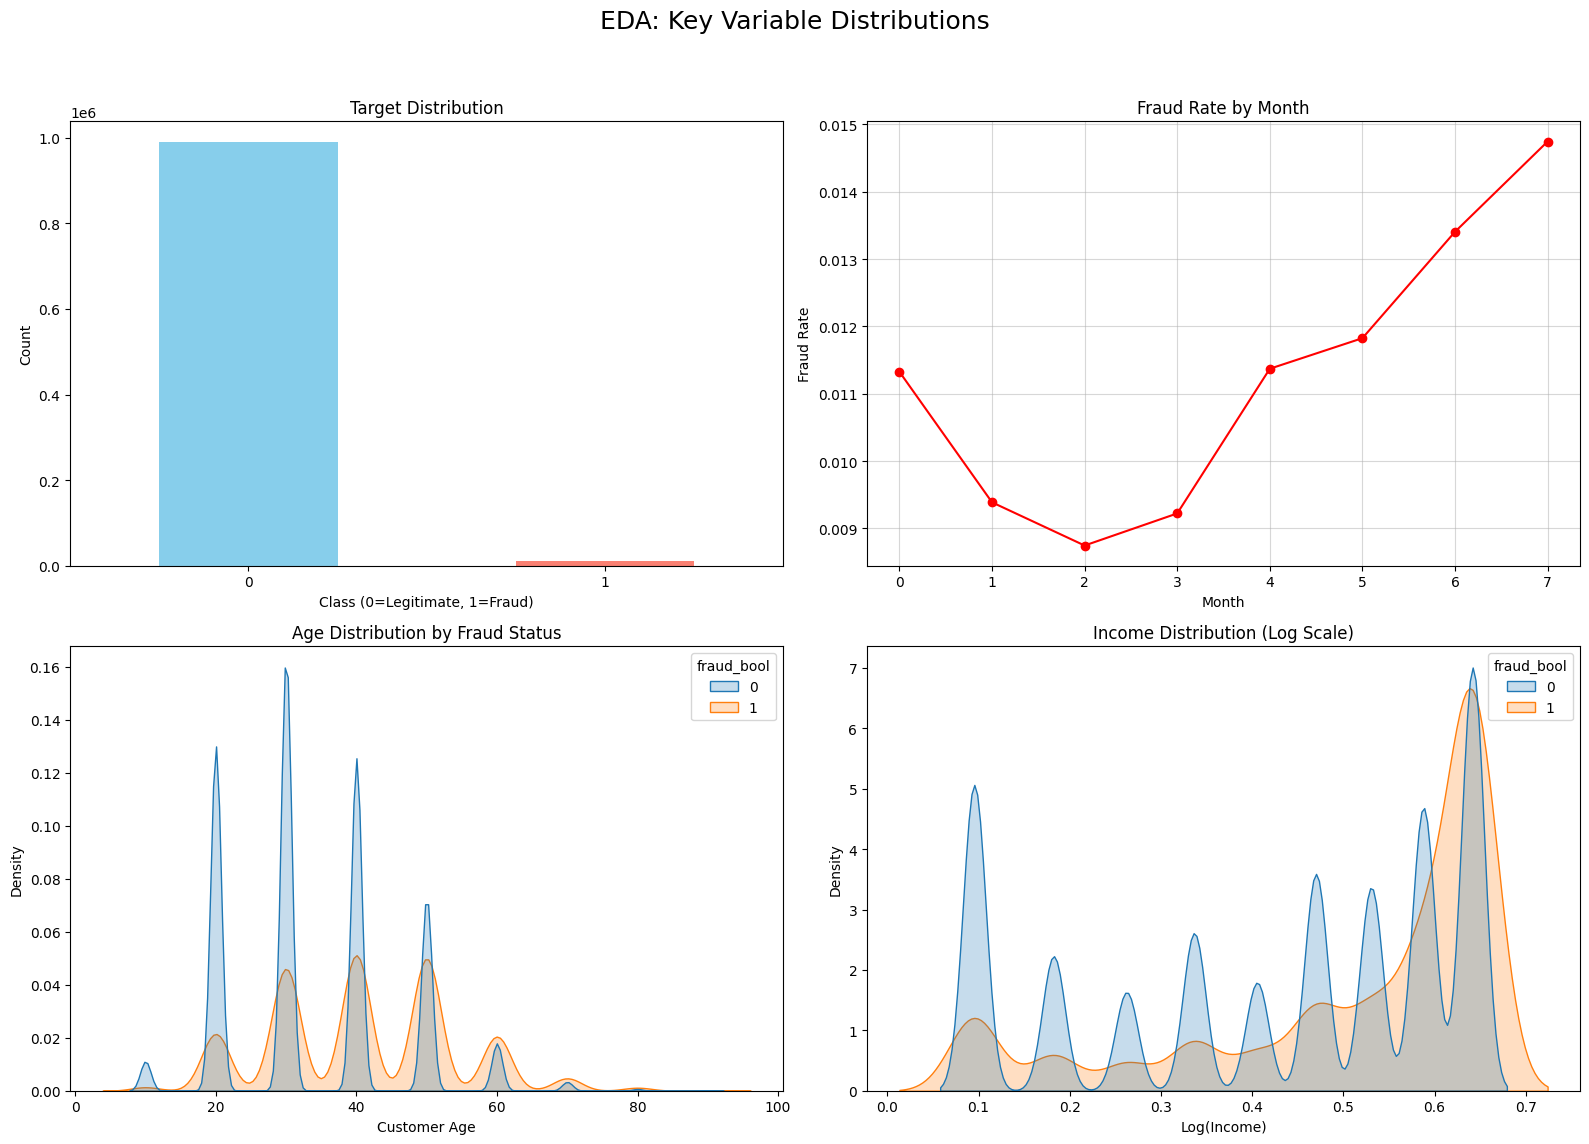

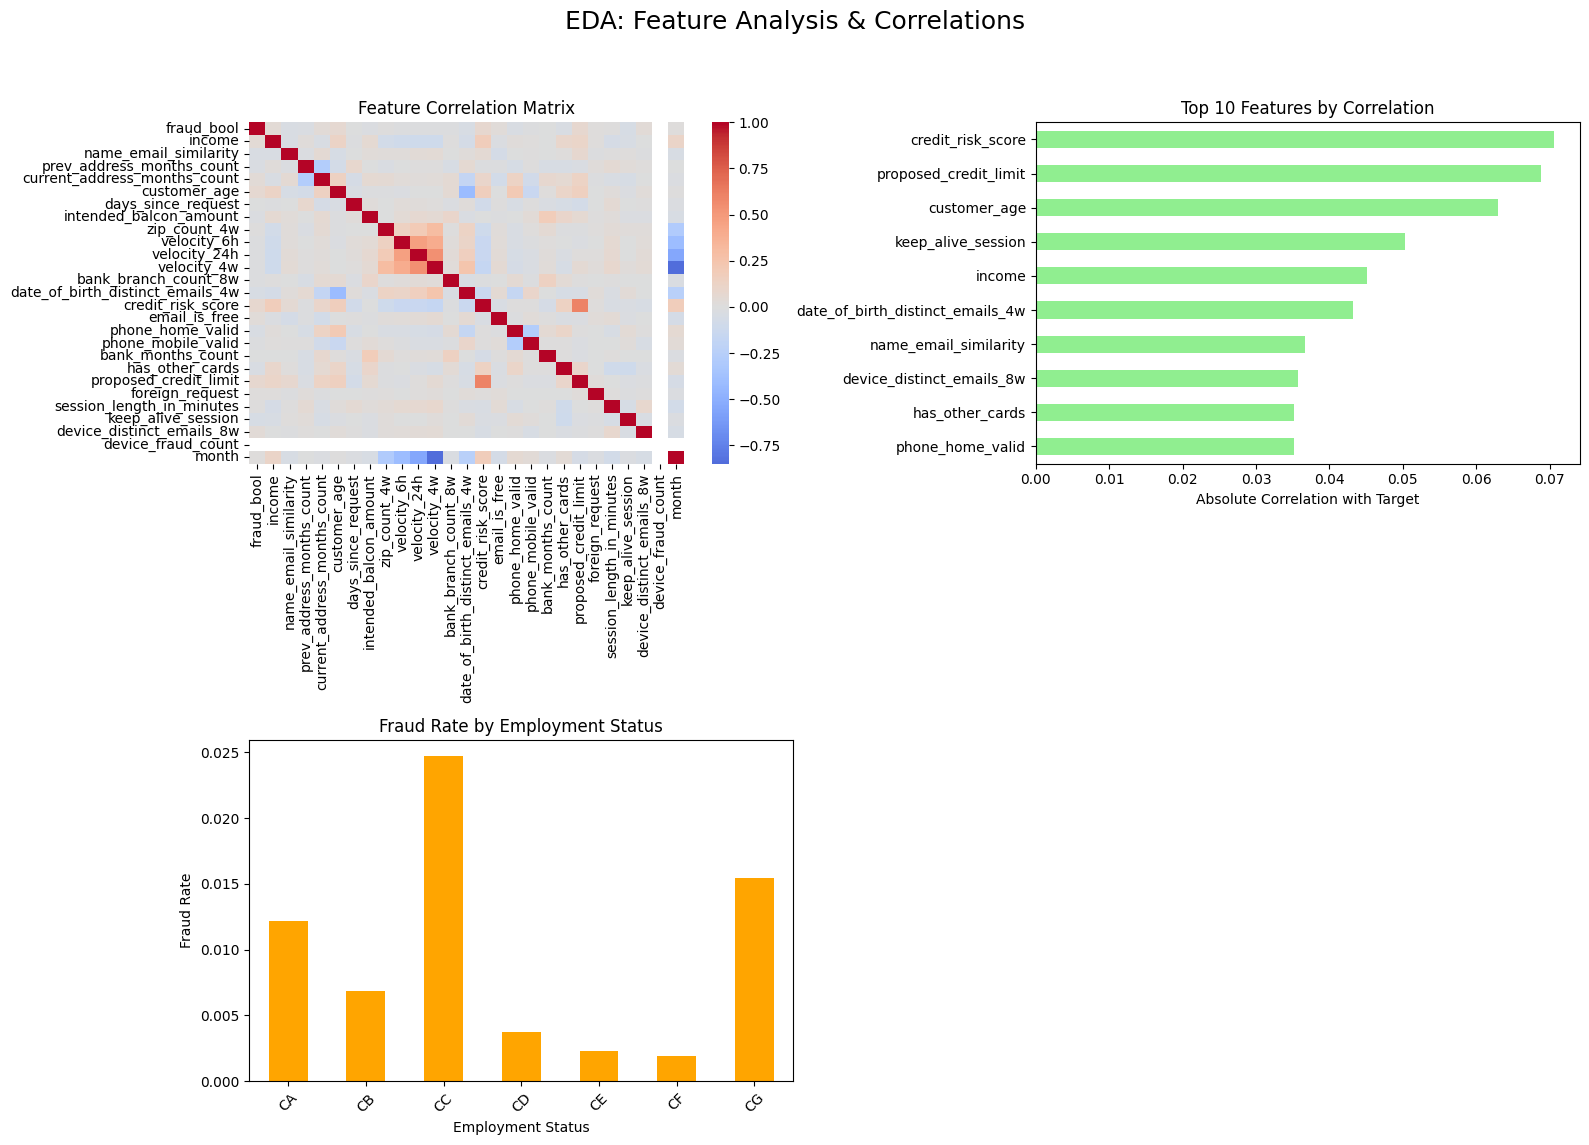

/tmp/ipython-input-371431213.py:110: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('age_group')[target_col].mean().plot(kind='bar', color='purple', ax=axes3[1])


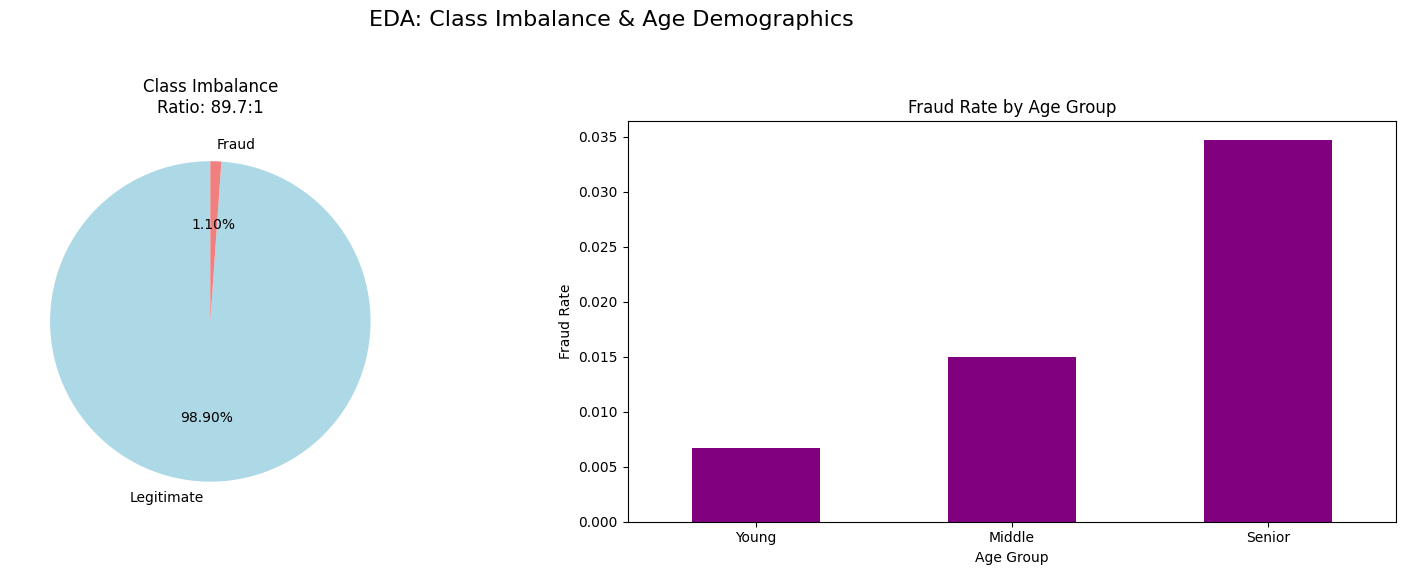

In [ ]:
eda(df, target_col)


In [ ]:
X, y, _, _ = preprocess_data(df, target_col)
# Use a stratified split to maintain class proportions
X_train, X_test, y_train, y_test = train_test_split(
   X, y, test_size=0.3, random_state=14, stratify=y
)
print(f"\nData split into training ({len(X_train)} samples) and testing ({len(X_test)} samples).")


--- Preprocessing Data ---
Found 5 categorical and 26 numerical columns.
✓ Categorical features encoded.
Applying StandardScaler to features...
✓ Preprocessing complete. Final feature shape: (1000000, 31)

Data split into training (700000 samples) and testing (300000 samples).


In [ ]:
models = train_models(X_train, X_test, y_train, y_test)


--- Training Machine Learning Models ---
1. Training Logistic Regression...
   ✓ Completed in 6.35s
2. Training XGBoost...


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [09:34:07] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


   ✓ Completed in 12.79s
3. Training Standard TensorFlow NN...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


   ✓ Completed in 1561.19s
4. Training Deep TensorFlow NN...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


   ✓ Completed in 2272.04s

--- Training Bayesian Neural Network (with MC Dropout) ---
Training Bayesian NN...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Performing Monte Carlo inference for uncertainty...
✓ Bayesian NN trained in 962.58s. AUC: 0.8559, F1: 0.0828

Evaluating model performance...
  Logistic Regression  -> AUC: 0.8580, F1: 0.0734, Precision: 0.0386, Recall: 0.7667
  XGBoost              -> AUC: 0.8888, F1: 0.0999, Precision: 0.0535, Recall: 0.7504
  TensorFlow NN        -> AUC: 0.8634, F1: 0.1059, Precision: 0.0574, Recall: 0.6857
  Deep TensorFlow NN   -> AUC: 0.8696, F1: 0.0817, Precision: 0.0431, Recall: 0.7854
  Bayesian NN          -> AUC: 0.8559, F1: 0.0828, Precision: 0.0439, Recall: 0.7129



--- Performing Threshold Tuning Analysis ---


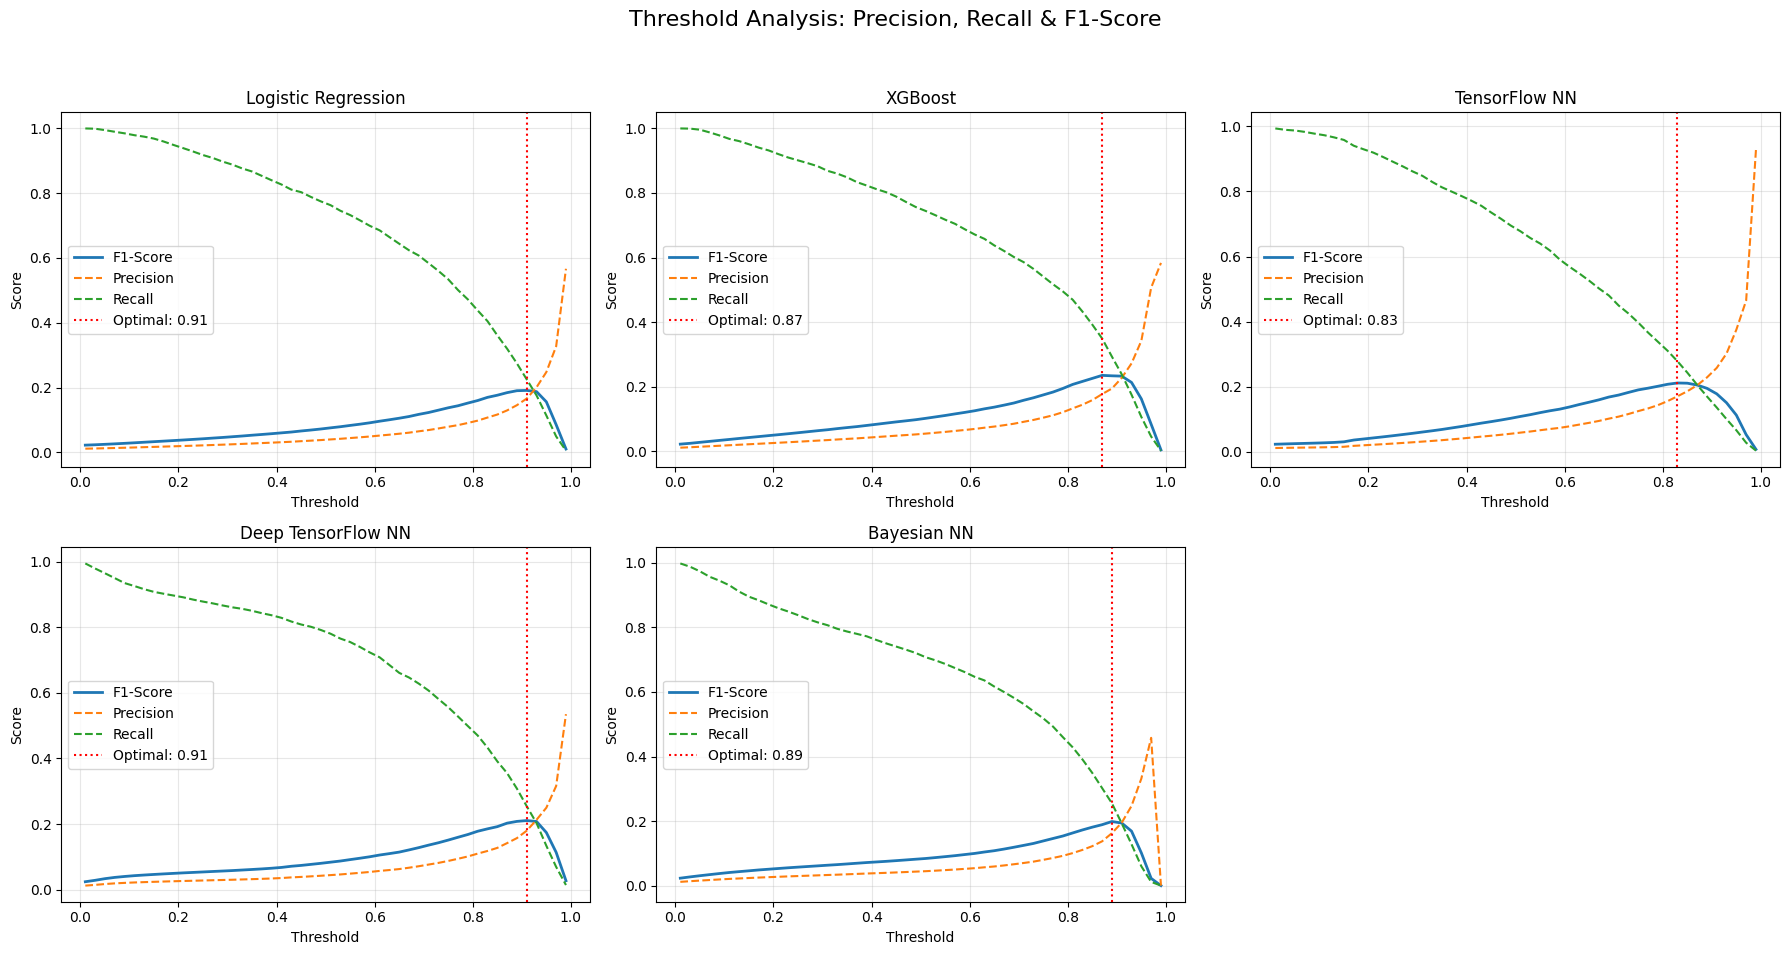

In [ ]:
threshold_analysis(models, y_test)


--- Performing Model Calibration Analysis ---


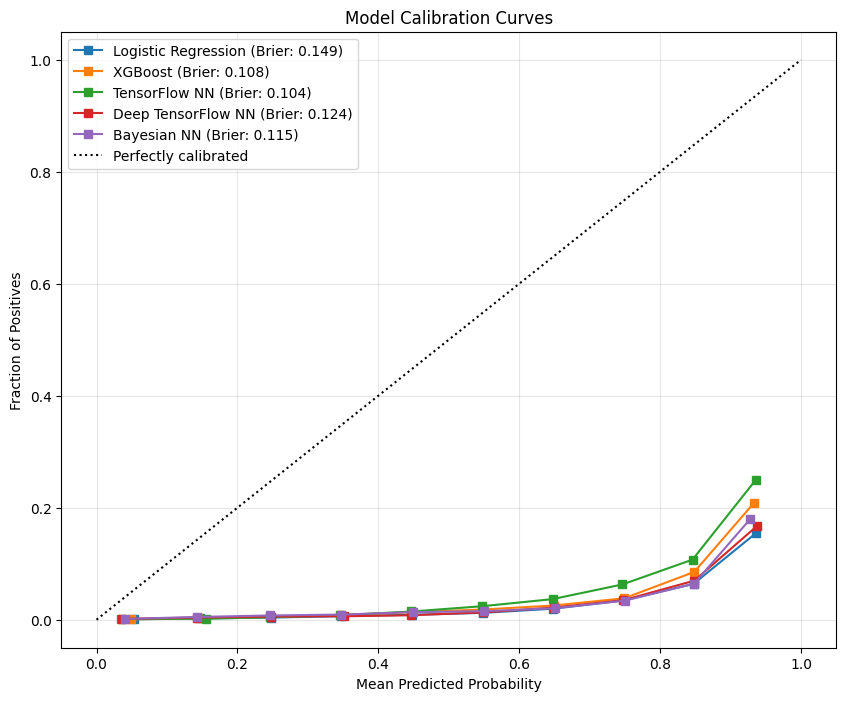

In [ ]:
calibration_analysis(models, y_test)

Analyzing fairness across: ['age_group']

--- Fairness Tests for: Logistic Regression ---

  Attribute: AGE_GROUP
    Chi-Square p-value: 0.0000 (Potential Bias)
    Demographic Parity p-value: 0.0000 (Potential Bias)
      - Positive Rate (Group 0): 12.92%
      - Positive Rate (Group 1): 34.29%
      - Difference (Effect Size): 21.37%

--- Fairness Tests for: XGBoost ---

  Attribute: AGE_GROUP
    Chi-Square p-value: 0.0000 (Potential Bias)
    Demographic Parity p-value: 0.0000 (Potential Bias)
      - Positive Rate (Group 0): 9.43%
      - Positive Rate (Group 1): 23.74%
      - Difference (Effect Size): 14.31%

--- Fairness Tests for: TensorFlow NN ---

  Attribute: AGE_GROUP
    Chi-Square p-value: 0.0000 (Potential Bias)
    Demographic Parity p-value: 0.0000 (Potential Bias)
      - Positive Rate (Group 0): 6.71%
      - Positive Rate (Group 1): 22.06%
      - Difference (Effect Size): 15.35%

--- Fairness Tests for: Deep TensorFlow NN ---

  Attribute: AGE_GROUP
    Chi-Squar

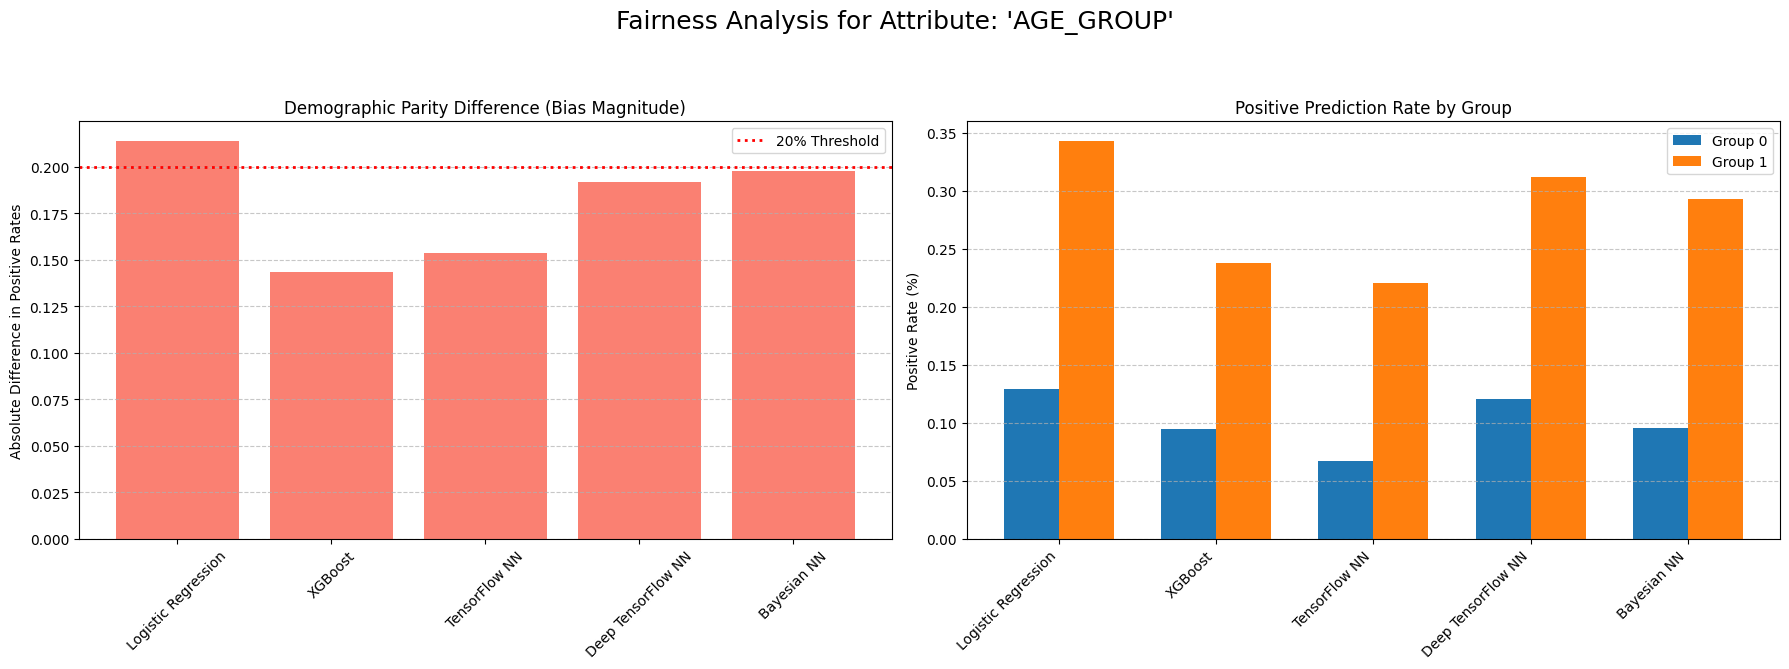

{'Logistic Regression': {'age_group': {'chi2_p_value': np.float64(0.0),
   'dp_p_value': np.float64(0.0),
   'dp_difference': np.float64(0.21368093538012506),
   'rate_group_0': np.float64(0.1292406084351233),
   'rate_group_1': np.float64(0.34292154381524836)}},
 'XGBoost': {'age_group': {'chi2_p_value': np.float64(0.0),
   'dp_p_value': np.float64(0.0),
   'dp_difference': np.float64(0.1430706479835813),
   'rate_group_0': np.float64(0.09433049089651993),
   'rate_group_1': np.float64(0.23740113888010123)}},
 'TensorFlow NN': {'age_group': {'chi2_p_value': np.float64(0.0),
   'dp_p_value': np.float64(0.0),
   'dp_difference': np.float64(0.15348759246693122),
   'rate_group_0': np.float64(0.06708342936160405),
   'rate_group_1': np.float64(0.22057102182853527)}},
 'Deep TensorFlow NN': {'age_group': {'chi2_p_value': np.float64(0.0),
   'dp_p_value': np.float64(0.0),
   'dp_difference': np.float64(0.19193115726284687),
   'rate_group_0': np.float64(0.1201140815856188),
   'rate_group_1

In [ ]:
statistical_fairness_analysis(models, X_test, y_test, df_original)


--- Comprehensive Evaluation Report ---

Model Performance Summary:
--------------------------------------------------------------------------------
Model                | AUC        | F1-Score   | Precision  | Recall     | Brier Score    
--------------------------------------------------------------------------------
Logistic Regression  | 0.8580     | 0.0734     | 0.0386    | 0.7667   | 0.1489
XGBoost              | 0.8888     | 0.0999     | 0.0535    | 0.7504   | 0.1077
TensorFlow NN        | 0.8634     | 0.1059     | 0.0574    | 0.6857   | 0.1037
Deep TensorFlow NN   | 0.8696     | 0.0817     | 0.0431    | 0.7854   | 0.1244
Bayesian NN          | 0.8559     | 0.0828     | 0.0439    | 0.7129   | 0.1152
--------------------------------------------------------------------------------


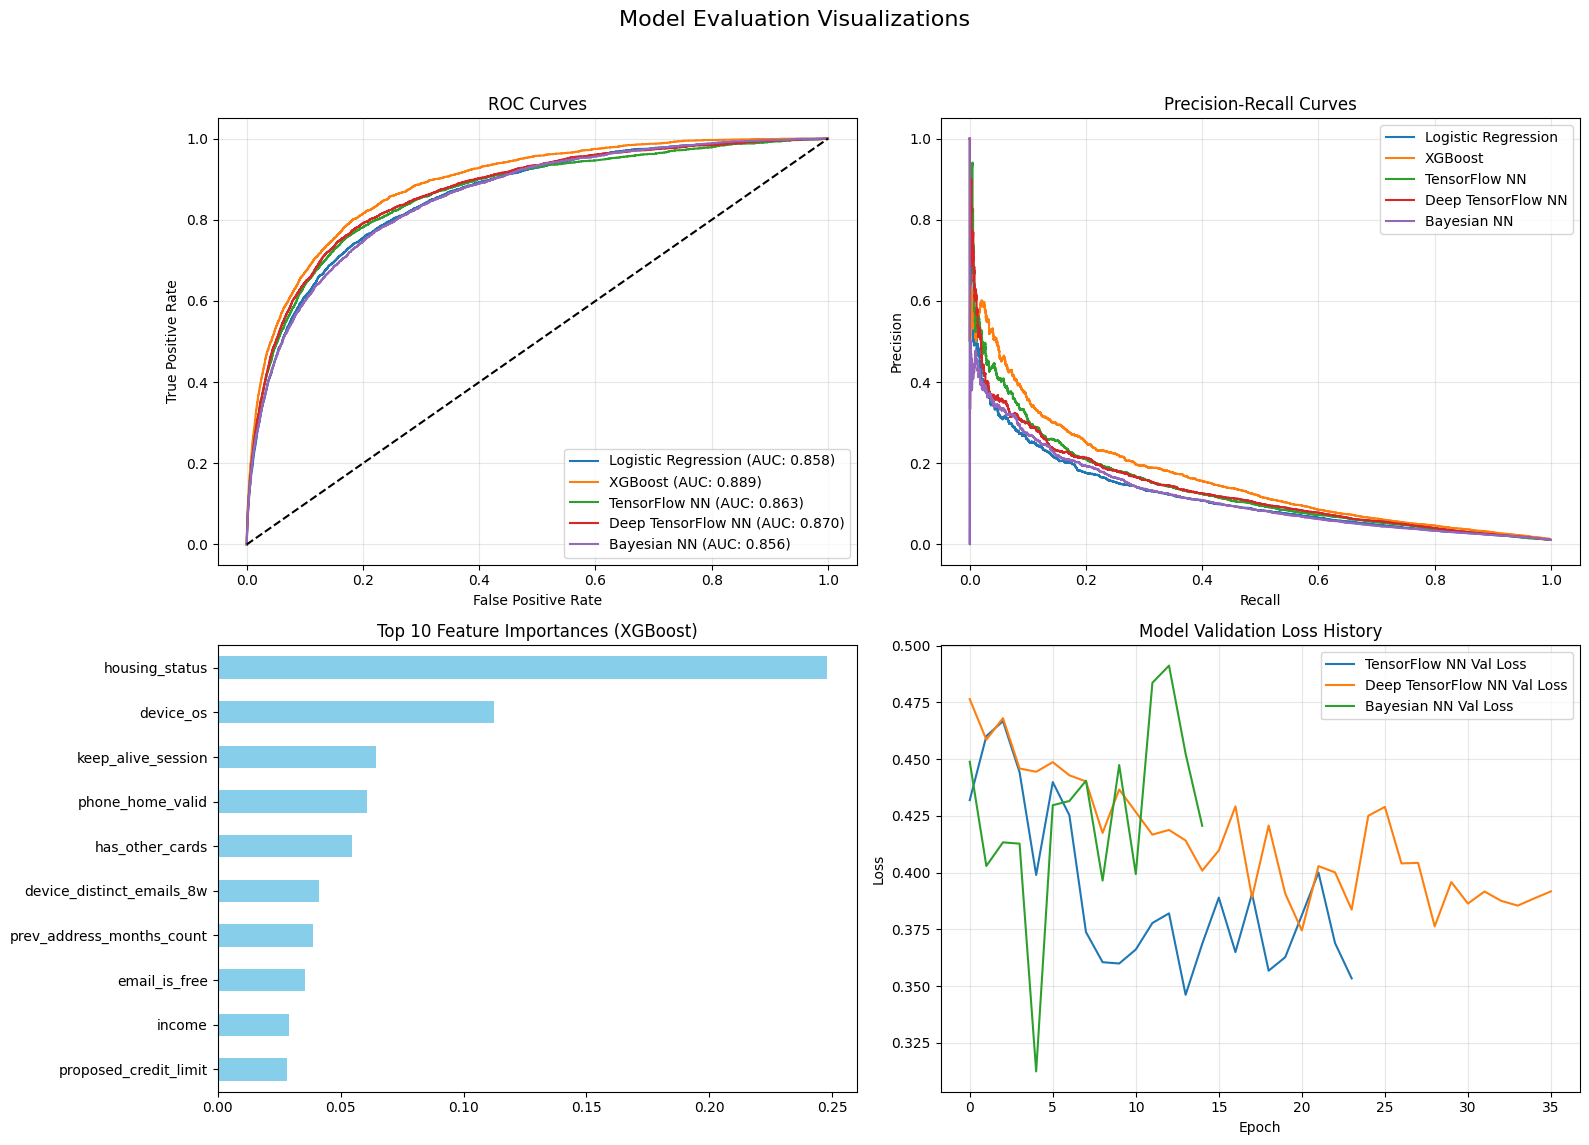

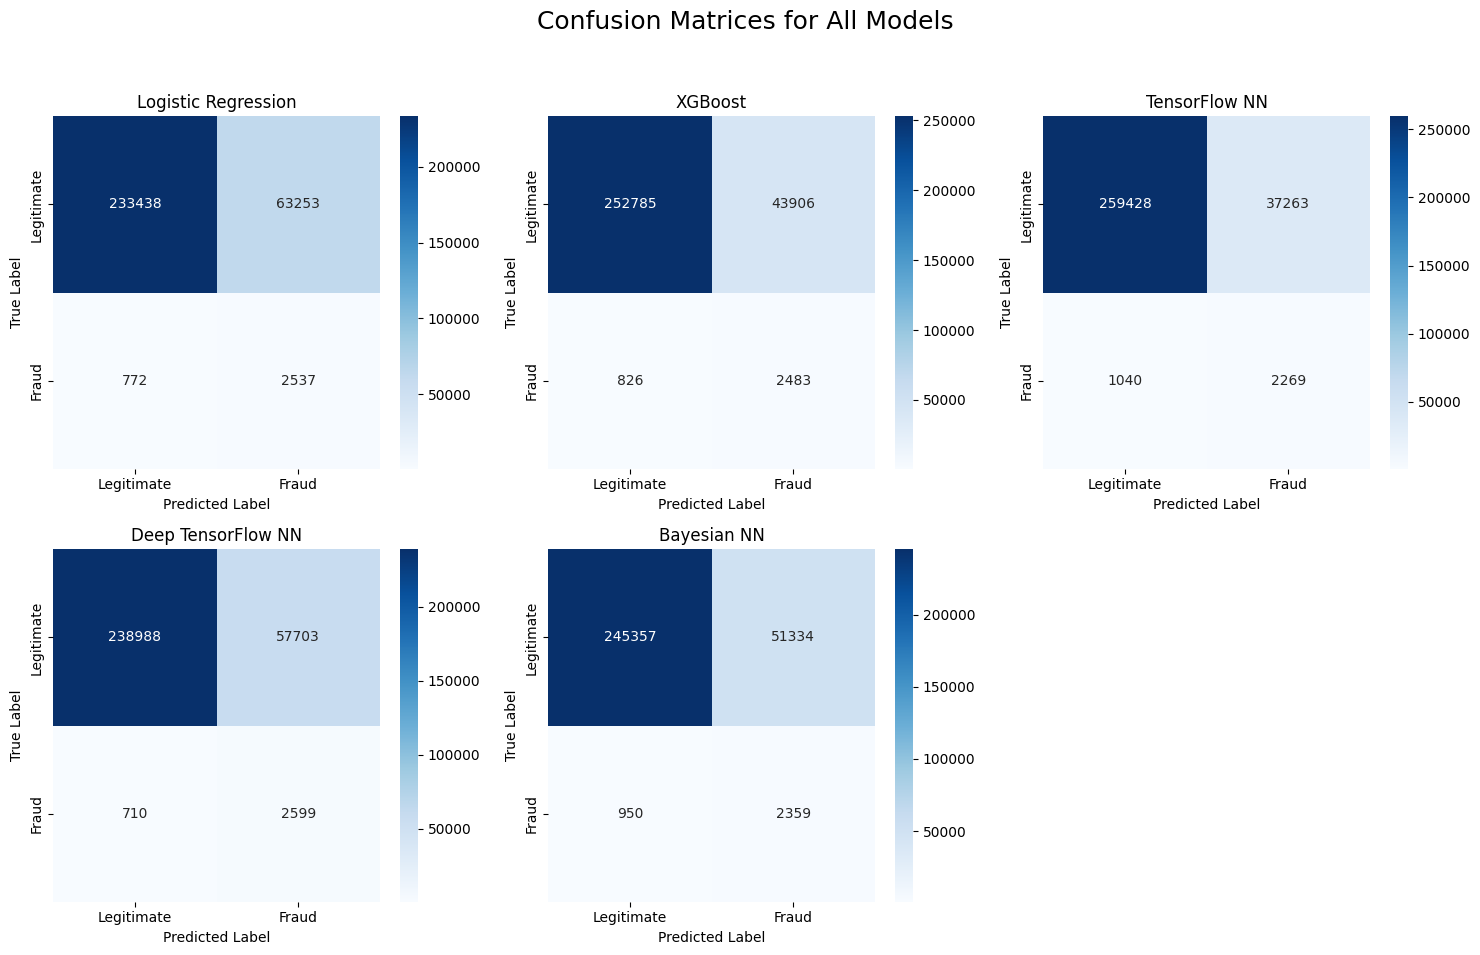

In [ ]:
comprehensive_evaluation_report(models, y_test)